In [1]:
import torch
import sys, os
import math as mt

src_dir = os.path.join(os.path.abspath(''), '..')  # goes up from models/ to src/
configs_dir = os.path.join(os.path.abspath(''), '../..')
sys.path.insert(0, os.path.abspath(src_dir))
sys.path.insert(0, os.path.abspath(configs_dir))

In [2]:
from models.autoencoder import Autoencoder
from models.autoencoder import trainSAE, testSAE
from utils.data_loading import QMatrixData

K = 5
lr = 5e-4
train_epochs = 500
in_channels = 4 
num_channels = 10
kernel_dim = 2
maze_dim = 4
batch_size = 10
gamma_sparse = 1/20*mt.sqrt(maze_dim**2*in_channels/K)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
import numpy as np
import random
seed = 39
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

In [4]:
BASE_DIR = os.path.abspath(os.path.join(os.path.abspath(''), '..', '..', '..'))

train_dataset = QMatrixData(
    q_file_path=os.path.join(BASE_DIR, "data/teacher/q matrix dictionaries/q_matricestraining_4x4.pkl"),
    label_file_path=os.path.join(BASE_DIR, "data/teacher/label dictionaries/q_matrices_labelstraining_4x4.pkl")
)
test_dataset = QMatrixData(
    q_file_path=os.path.join(BASE_DIR, "data/teacher/q matrix dictionaries/q_matricestest_4x4.pkl"),
    label_file_path=os.path.join(BASE_DIR, "data/teacher/label dictionaries/q_matrices_labelstest_4x4.pkl")
)

autoencoder = Autoencoder(in_channels, maze_dim, num_channels, kernel_dim, K)
optimizer = torch.optim.Adam(autoencoder.parameters(), lr=lr)

# training language
total_losses, recon_losses, sparsity_losses, all_messages = trainSAE(autoencoder, train_dataset, gamma_sparse, optimizer, batch_size, train_epochs, device)

# getting messages from trained language
_, _, _, all_messages, message_dict = testSAE(autoencoder, train_dataset, batch_size, gamma_sparse, device)

In [ ]:
from configs.experiment_config import ExperimentConfig
from rl.teacher import generate_q_matrices
from evaluation.student_eval import train_student, run_evaluations
    
config = ExperimentConfig()
q_matrices, label_dict, wall_state_dict, sopt_dict = generate_q_matrices(config, device)
student = train_student(label_dict, wall_state_dict, sopt_dict, message_dict, config, device)

Completed calculation of deterministic Q-matrices
Precomputing analytical task environments...


Precomputing tasks: 100%|██████████| 225/225 [00:00<00:00, 836.28it/s]


Training analytical student simultaneously on 225 tasks...


Training student (epochs):   7%|▋         | 50/750 [00:13<03:03,  3.81it/s]

Epoch 50/750 completed


...

Epoch 650/750 completed


Training student (epochs):  93%|█████████▎| 700/750 [03:08<00:14,  3.38it/s]

Epoch 700/750 completed


Training student (epochs): 100%|██████████| 750/750 [03:22<00:00,  3.71it/s]

Epoch 750/750 completed


In [6]:
import importlib
import evaluation.student_eval as student_eval
importlib.reload(student_eval)
from evaluation.student_eval import train_student, run_evaluations

informed_rates, misinformed_rates = run_evaluations(student, label_dict, wall_state_dict, message_dict, sopt_dict, config, device)

Informed student:    65.86%
Misinformed student: 37.65%


In [7]:
autoencoder, student = student_eval.train_student_with_feedback(
    label_dict, 
    wall_state_dict, 
    sopt_dict, 
    q_matrices,
    autoencoder, 
    student, 
    config, 
    device,
)

Precomputing analytical task environments for joint training...


Precomputing tasks: 100%|██████████| 225/225 [00:00<00:00, 811.01it/s]


Training joint system on 225 tasks...


Joint Training (Epochs): 100%|██████████| 750/750 [13:23<00:00,  1.07s/it]


In [8]:
# Extract the optimized messages generated by the newly trained Autoencoder
message_dict_feedback = {}
autoencoder.eval()
with torch.no_grad():
    for task, (wall_label, init_state, goal_state) in label_dict.items():
        q_mat = q_matrices[task].unsqueeze(0).to(device)
        message, _ = autoencoder(q_mat)
        message_dict_feedback[(wall_label, init_state, goal_state)] = message.squeeze(0).detach()

In [10]:
informed_rates, misinformed_rates = student_eval.run_evaluations(
    student, label_dict, wall_state_dict, message_dict_feedback, sopt_dict, config, device
)

Informed student:    94.11%
Misinformed student: 32.34%


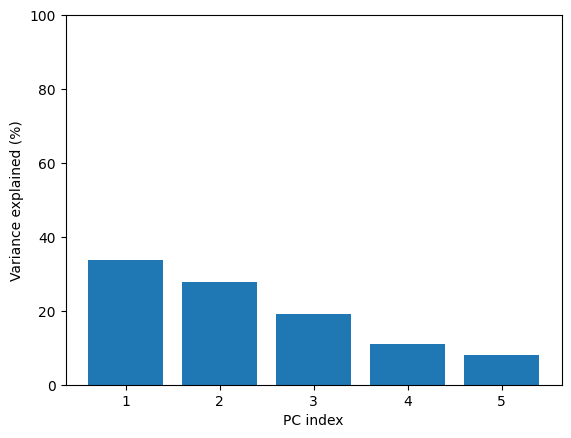

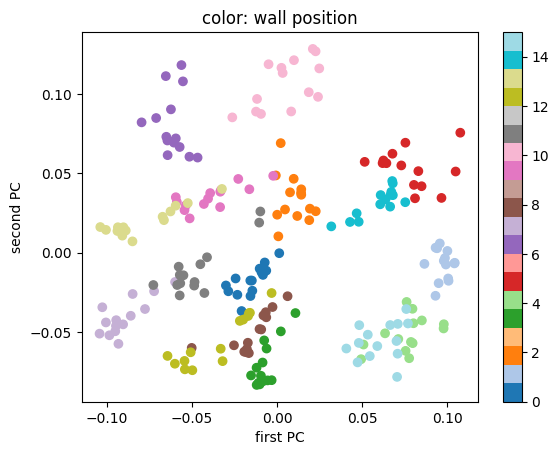

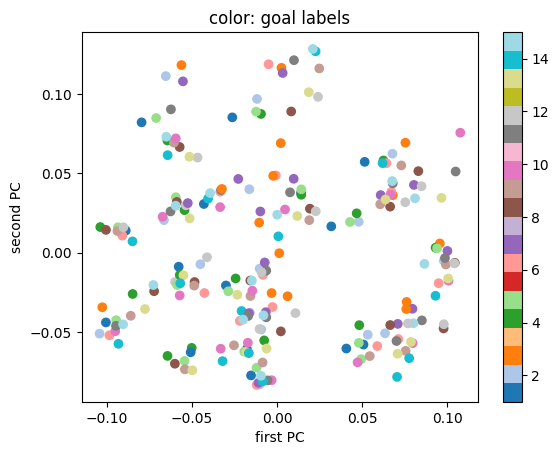

In [9]:
from sklearn.decomposition import PCA
from utils.plotting import plot_pca_variance, plot_pca_by_label

# Stack all messages into a single tensor
messages = torch.cat(all_messages, dim=0)  # shape: (num_tasks, K)
messages_np = messages.numpy()

wall_labels = [train_dataset.labels[i][0] for i in range(225)]
goal_labels = [train_dataset.labels[i][2] for i in range(225)]

pca = PCA(n_components=5)
pca_result = pca.fit_transform(messages_np)

# get plots
plot_pca_variance(pca)
plot_pca_by_label(pca_result, wall_labels, "color: wall position")
plot_pca_by_label(pca_result, goal_labels, "color: goal labels")